In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm

In [5]:
DATASET_PATH="../data/classification"

In [6]:
train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_dir = os.path.join(DATASET_PATH, "test")

## Number of Class

In [7]:
classes = os.listdir(train_dir)

print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 102
['0', '1', '10', '100', '101', '11', '12', '13', '14', '15']


## Class Distribution

In [8]:
class_counts = {}

for class_name in classes:
    class_path = os.path.join(train_dir, class_name)

    num_images = len(os.listdir(class_path))

    class_counts[class_name] = num_images

class_counts

{'0': 669,
 '1': 292,
 '10': 513,
 '100': 274,
 '101': 3444,
 '11': 242,
 '12': 103,
 '13': 245,
 '14': 516,
 '15': 989,
 '16': 532,
 '17': 88,
 '18': 512,
 '19': 294,
 '2': 156,
 '20': 287,
 '21': 317,
 '22': 1018,
 '23': 642,
 '24': 2456,
 '25': 339,
 '26': 414,
 '27': 392,
 '28': 195,
 '29': 424,
 '3': 631,
 '30': 291,
 '31': 139,
 '32': 147,
 '33': 175,
 '34': 203,
 '35': 82,
 '36': 62,
 '37': 473,
 '38': 513,
 '39': 962,
 '4': 302,
 '40': 179,
 '41': 162,
 '42': 184,
 '43': 114,
 '44': 314,
 '45': 639,
 '46': 393,
 '47': 492,
 '48': 836,
 '49': 392,
 '5': 303,
 '50': 845,
 '51': 1138,
 '52': 156,
 '53': 106,
 '54': 527,
 '55': 111,
 '56': 281,
 '57': 228,
 '58': 840,
 '59': 212,
 '6': 221,
 '60': 105,
 '61': 47,
 '62': 169,
 '63': 50,
 '64': 184,
 '65': 84,
 '66': 458,
 '67': 3186,
 '68': 690,
 '69': 767,
 '7': 500,
 '70': 3048,
 '71': 415,
 '72': 42,
 '73': 269,
 '74': 231,
 '75': 103,
 '76': 433,
 '77': 251,
 '78': 154,
 '79': 135,
 '8': 535,
 '80': 44,
 '81': 59,
 '82': 414,
 '

## Class Graph

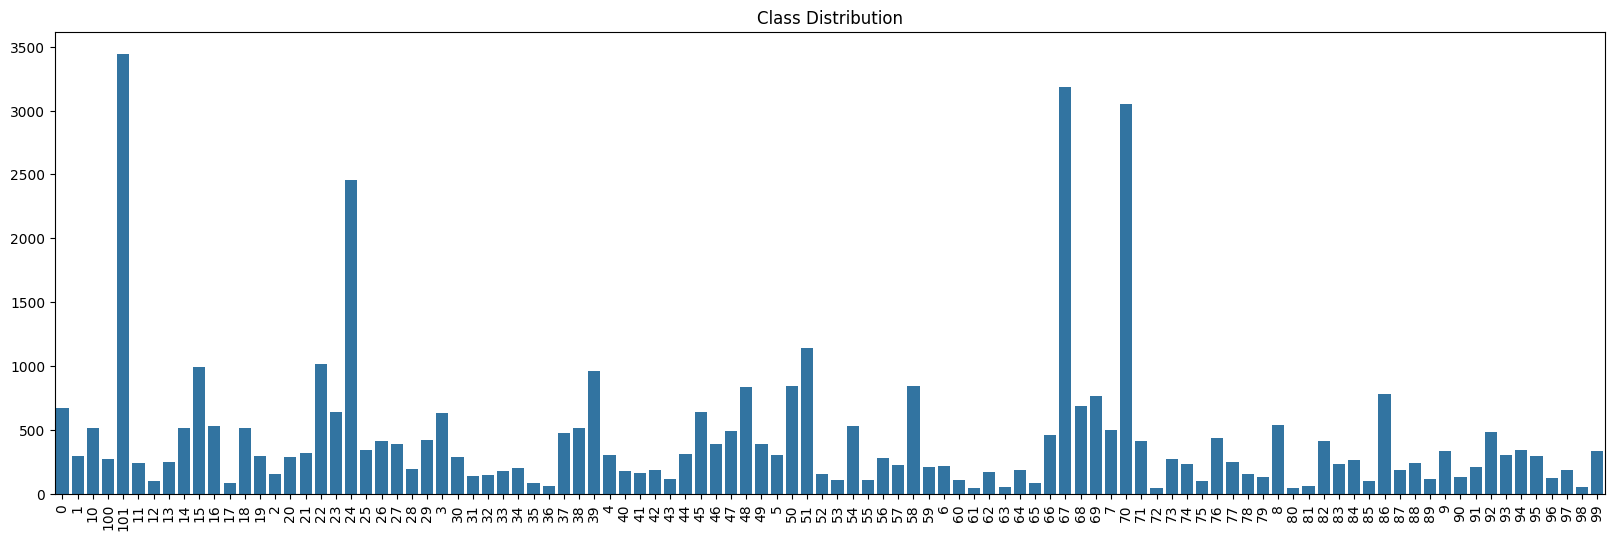

In [9]:
plt.figure(figsize=(20,6))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

In [10]:
sorted_counts = dict(
    sorted(class_counts.items(), key=lambda x: x[1])
)

sorted_counts

{'72': 42,
 '80': 44,
 '61': 47,
 '63': 50,
 '98': 55,
 '81': 59,
 '36': 62,
 '35': 82,
 '65': 84,
 '17': 88,
 '85': 100,
 '12': 103,
 '75': 103,
 '60': 105,
 '53': 106,
 '55': 111,
 '89': 113,
 '43': 114,
 '96': 126,
 '79': 135,
 '90': 135,
 '31': 139,
 '32': 147,
 '78': 154,
 '2': 156,
 '52': 156,
 '41': 162,
 '62': 169,
 '33': 175,
 '40': 179,
 '97': 183,
 '42': 184,
 '64': 184,
 '87': 186,
 '28': 195,
 '34': 203,
 '91': 210,
 '59': 212,
 '6': 221,
 '57': 228,
 '74': 231,
 '83': 232,
 '11': 242,
 '88': 242,
 '13': 245,
 '77': 251,
 '84': 263,
 '73': 269,
 '100': 274,
 '56': 281,
 '20': 287,
 '30': 291,
 '1': 292,
 '95': 292,
 '19': 294,
 '4': 302,
 '5': 303,
 '93': 303,
 '44': 314,
 '21': 317,
 '9': 331,
 '99': 333,
 '25': 339,
 '94': 346,
 '27': 392,
 '49': 392,
 '46': 393,
 '26': 414,
 '82': 414,
 '71': 415,
 '29': 424,
 '76': 433,
 '66': 458,
 '37': 473,
 '92': 484,
 '47': 492,
 '7': 500,
 '18': 512,
 '10': 513,
 '38': 513,
 '14': 516,
 '54': 527,
 '16': 532,
 '8': 535,
 '3': 631

In [11]:
smallest_10 = list(sorted_counts.items())[:10]

print("Smallest Classes:\n")

for cls, count in smallest_10:
    print(f"Class {cls}: {count}")

Smallest Classes:

Class 72: 42
Class 80: 44
Class 61: 47
Class 63: 50
Class 98: 55
Class 81: 59
Class 36: 62
Class 35: 82
Class 65: 84
Class 17: 88


In [12]:
largest_10 = list(sorted_counts.items())[-10:]

print("Largest Classes:\n")

for cls, count in largest_10:
    print(f"Class {cls}: {count}")

Largest Classes:

Class 58: 840
Class 50: 845
Class 39: 962
Class 15: 989
Class 22: 1018
Class 51: 1138
Class 24: 2456
Class 70: 3048
Class 67: 3186
Class 101: 3444


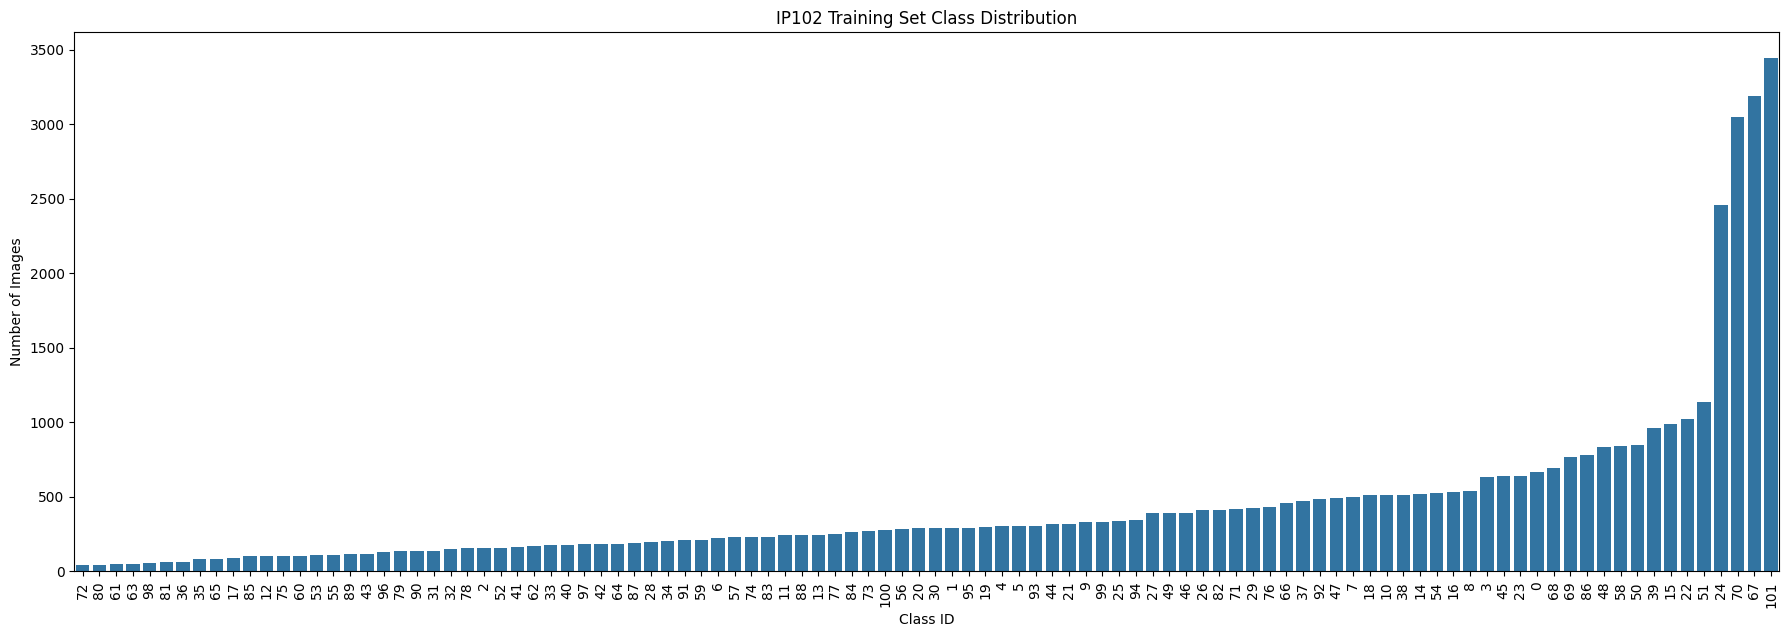

In [13]:
plt.figure(figsize=(22,7))

sns.barplot(
    x=list(sorted_counts.keys()),
    y=list(sorted_counts.values())
)

plt.xticks(rotation=90)

plt.title("IP102 Training Set Class Distribution")

plt.xlabel("Class ID")
plt.ylabel("Number of Images")

plt.show()

In [14]:
counts = list(class_counts.values())

print("Total Classes:", len(class_counts))
print("Total Images:", sum(counts))

print("Average Images per Class:", np.mean(counts))

print("Median Images:", np.median(counts))

print("Minimum Images:", np.min(counts))

print("Maximum Images:", np.max(counts))

Total Classes: 102
Total Images: 45095
Average Images per Class: 442.1078431372549
Median Images: 289.0
Minimum Images: 42
Maximum Images: 3444


In [15]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [16]:
img_size = 224
train_transform = A.Compose([
    # Aspect Ratio'yu koruyarak boyutlandırma
    A.LongestMaxSize(max_size=img_size + 32, p=1.0),
    A.PadIfNeeded(min_height=img_size + 32, min_width=img_size + 32, border_mode=cv2.BORDER_CONSTANT, value=0, p=1.0),
    A.RandomCrop(width=img_size, height=img_size, p=1.0),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.5),

    A.OneOf([
        A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=1.0),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0), # Lighting variation için
    ], p=0.6),

    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        A.MotionBlur(blur_limit=5, p=1.0),
    ], p=0.3),

    # ViT için Regularization (Visually similar insects sorununu zorlamak için)
    A.CoarseDropout(max_holes=4, max_height=int(img_size*0.2), max_width=int(img_size*0.2), min_holes=1, fill_value=0, p=0.5),

    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

C:\Users\Asus\AppData\Local\Temp\ipykernel_20740\231692448.py:5: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=img_size + 32, min_width=img_size + 32, border_mode=cv2.BORDER_CONSTANT, value=0, p=1.0),
c:\Users\Asus\OneDrive\Masaüstü\capstone_final\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\Asus\AppData\Local\Temp\ipykernel_20740\231692448.py:19: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
C:\Users\Asus\AppData\Local\Temp\ipykernel_20740\231692448.py:25: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=int(img_size*0.2), max_width=int(img_size*0.2), min_holes=1, fill_

In [17]:
img_size = 224
val_transform = A.Compose([
    A.LongestMaxSize(max_size=img_size, p=1.0),
    A.PadIfNeeded(min_height=img_size, min_width=img_size, border_mode=cv2.BORDER_CONSTANT, value=0, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

C:\Users\Asus\AppData\Local\Temp\ipykernel_20740\3232387889.py:4: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=img_size, min_width=img_size, border_mode=cv2.BORDER_CONSTANT, value=0, p=1.0),


In [18]:
class IP102Dataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d)) and not d.startswith('.')
        ])

        self.image_paths = []
        self.labels = []

        for label, class_name in enumerate(self.classes):

            class_path = os.path.join(root_dir, class_name)

            for image_name in os.listdir(class_path):
                if image_name.startswith('.'): continue

                image_path = os.path.join(
                    class_path,
                    image_name
                )

                self.image_paths.append(image_path)

                self.labels.append(label)

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image_path = self.image_paths[idx]

        label = self.labels[idx]

        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        if self.transform:

            augmented = self.transform(image=image)

            image = augmented["image"]

        return image, label

In [19]:
train_dataset = IP102Dataset(
    train_dir,
    transform=train_transform
)

val_dataset = IP102Dataset(
    val_dir,
    transform=val_transform
)

test_dataset = IP102Dataset(
    test_dir,
    transform=val_transform
)

In [20]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
0


In [21]:
from torch.utils.data import WeightedRandomSampler

In [22]:
train_labels = train_dataset.labels

In [23]:
class_counts = Counter(train_labels)

class_counts

Counter({4: 3444,
         66: 3186,
         70: 3048,
         19: 2456,
         49: 1138,
         17: 1018,
         9: 989,
         35: 962,
         48: 845,
         56: 840,
         45: 836,
         87: 782,
         68: 767,
         67: 690,
         0: 669,
         18: 642,
         42: 639,
         25: 631,
         80: 535,
         10: 532,
         52: 527,
         8: 516,
         2: 513,
         34: 513,
         12: 512,
         69: 500,
         44: 492,
         94: 484,
         33: 473,
         65: 458,
         76: 433,
         24: 424,
         71: 415,
         21: 414,
         83: 414,
         43: 393,
         22: 392,
         46: 392,
         96: 346,
         20: 339,
         101: 333,
         91: 331,
         16: 317,
         41: 314,
         47: 303,
         95: 303,
         36: 302,
         13: 294,
         1: 292,
         97: 292,
         26: 291,
         15: 287,
         54: 281,
         3: 274,
         73: 269,
         8

In [24]:
class_weights = {}

for cls, count in class_counts.items():

    class_weights[cls] = 1.0 / count

In [25]:
sample_weights = [
    class_weights[label]
    for label in train_labels
]

In [26]:
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [28]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


## Advanced EDA: Image Dimensions and Aspect Ratios
Understanding image resolutions and aspect ratios is critical for ViT preprocessing.

Analyzing image sizes: 100%|██████████| 1000/1000 [00:00<00:00, 1454.70it/s]


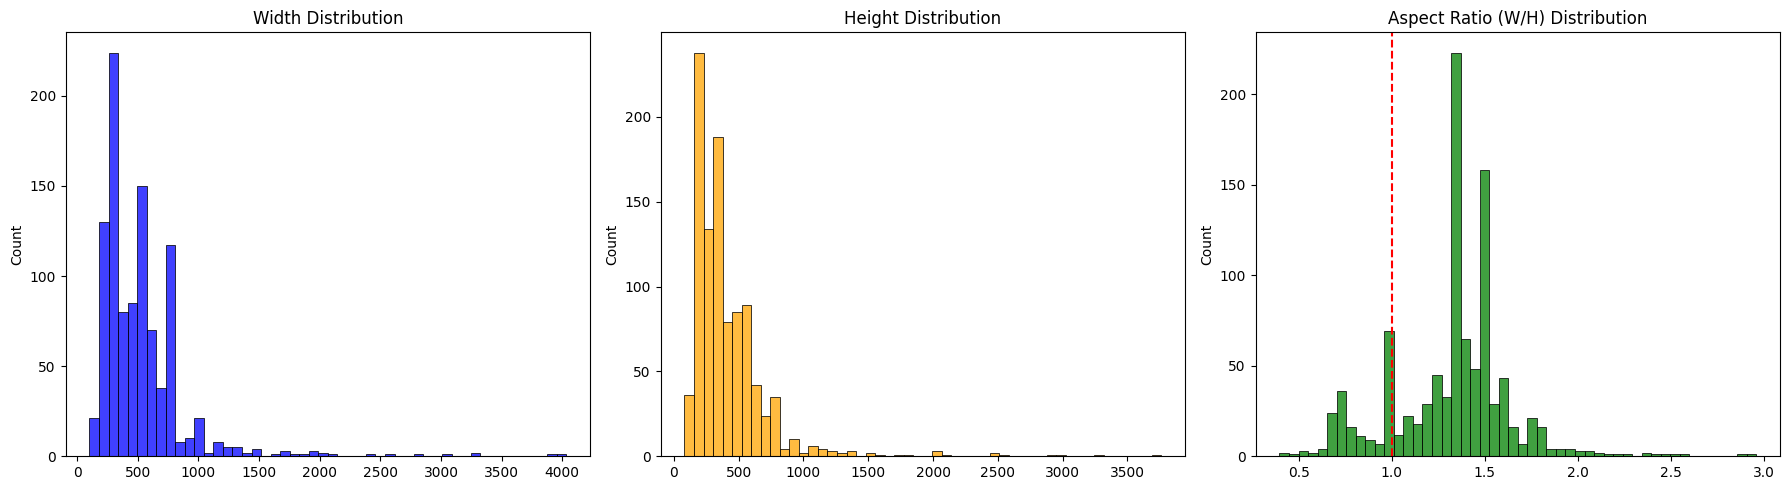

In [29]:
from PIL import Image
import random

widths, heights, aspect_ratios = [], [], []

# Sample 1000 images to estimate distribution
all_train_paths = []
for cls in classes:
    p = os.path.join(train_dir, cls)
    if os.path.isdir(p):
        all_train_paths.extend([os.path.join(p, img) for img in os.listdir(p) if img.endswith('.jpg')])

sampled_paths = random.sample(all_train_paths, min(1000, len(all_train_paths)))

for path in tqdm(sampled_paths, desc='Analyzing image sizes'):
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(widths, bins=50, ax=axes[0], color='blue')
axes[0].set_title('Width Distribution')
sns.histplot(heights, bins=50, ax=axes[1], color='orange')
axes[1].set_title('Height Distribution')
sns.histplot(aspect_ratios, bins=50, ax=axes[2], color='green')
axes[2].set_title('Aspect Ratio (W/H) Distribution')
axes[2].axvline(1.0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

## Advanced EDA: Visualizing Data Augmentation
Let's check how our advanced ViT augmentation pipeline handles the images.

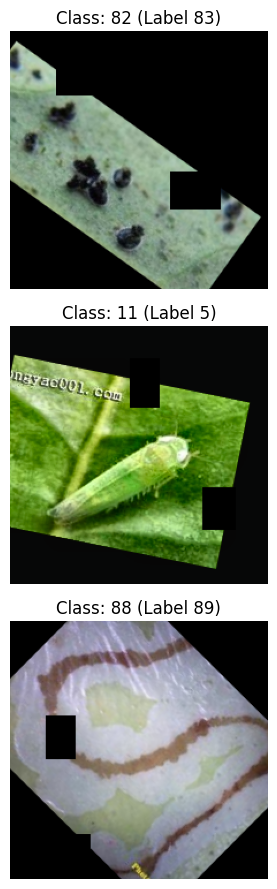

In [30]:
def visualize_augmentations(dataset, num_samples=5):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    plt.figure(figsize=(15, 3 * num_samples))
    for i in range(num_samples):
        idx = np.random.randint(len(dataset))
        img_tensor, label = dataset[idx]
        img = img_tensor.permute(1, 2, 0).numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        plt.subplot(num_samples, 1, i+1)
        plt.imshow(img)
        plt.title(f"Class: {dataset.classes[label]} (Label {label})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_augmentations(train_dataset, num_samples=3)

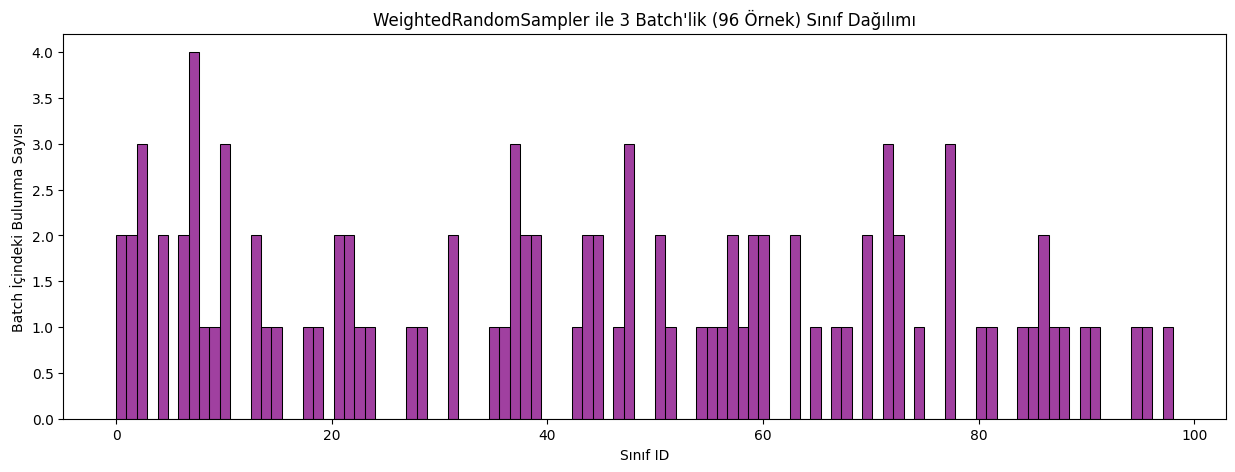

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# DataLoader'dan 3 batch (3x32 = 96 resim) çekelim
all_sampled_labels = []
for i, (images, labels) in enumerate(train_loader):
    all_sampled_labels.extend(labels.numpy())
    if i == 2: # 3 batch yeterli
        break

plt.figure(figsize=(15, 5))
sns.histplot(all_sampled_labels, bins=102, color="purple", kde=False)
plt.title("WeightedRandomSampler ile 3 Batch'lik (96 Örnek) Sınıf Dağılımı")
plt.xlabel("Sınıf ID")
plt.ylabel("Batch İçindeki Bulunma Sayısı")
plt.show()


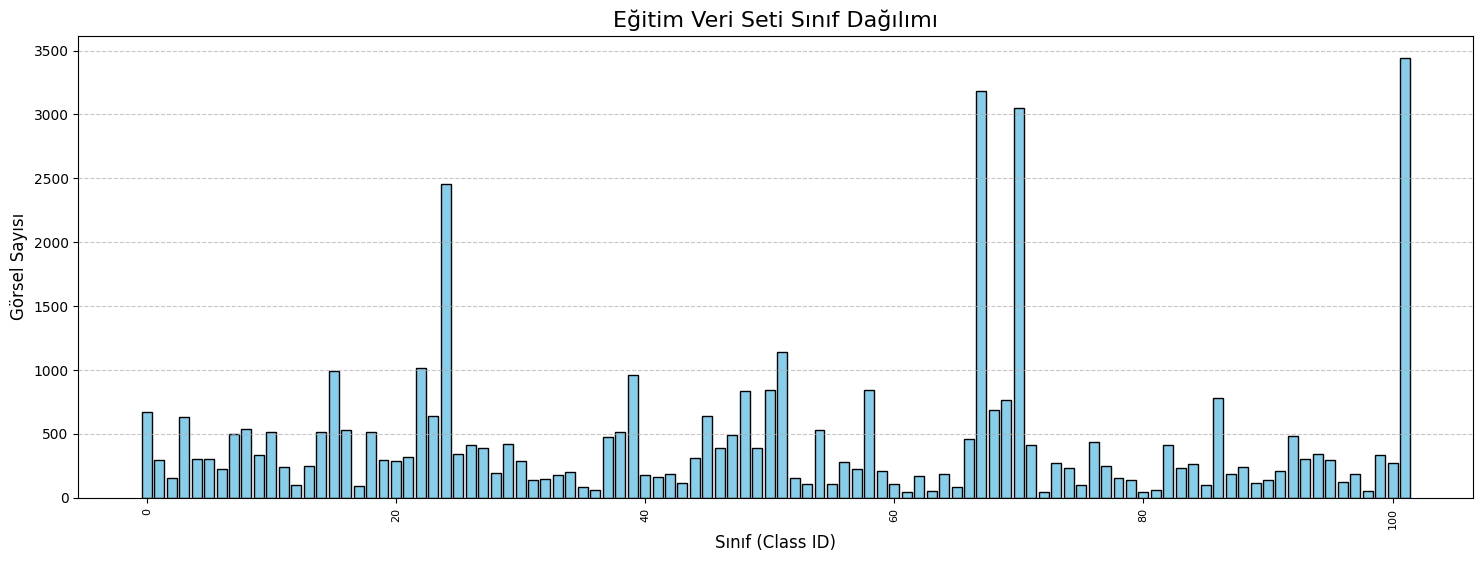


Augmentation Uygulanmış Örnek Eğitim Görselleri:


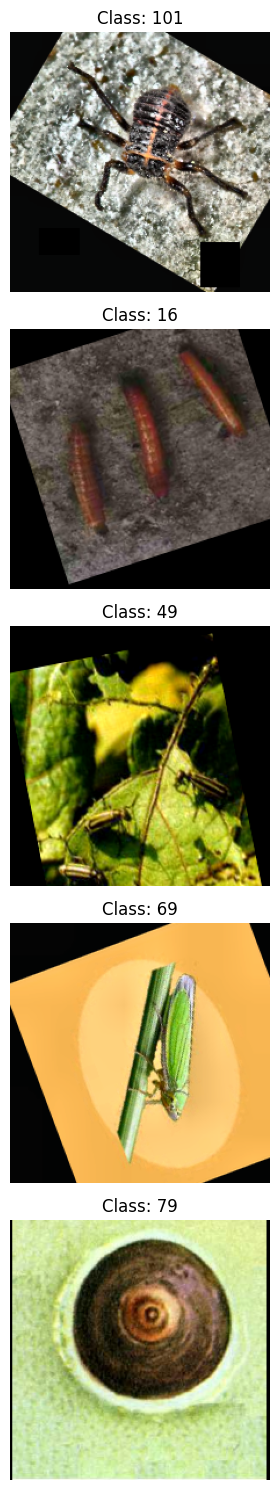

In [33]:
import sys
import os
import matplotlib.pyplot as plt
from collections import Counter

# Notebook klasörü içindeyiz, ana klasördeki dataset.py'yi okumak için yolu ekliyoruz
sys.path.append('..')
from dataset import IP102Dataset, get_transforms, visualize_augmentations

# Veri setinin yolu
data_dir = '../data/classification'
train_dir = os.path.join(data_dir, 'train')

# Augmentation kurallarını getir
train_transform, _ = get_transforms(img_size=224)

# Eğitim veri setini augmentation ile birlikte yükle
train_dataset = IP102Dataset(train_dir, transform=train_transform)

# ---------------------------------------------------------
# 1. Veri Seti Dağılımını Çiz (Class Distribution)
# ---------------------------------------------------------
class_counts = Counter(train_dataset.labels)

# Sınıfları ve veri sayılarını grafiğe dökmek için sıralayalım
classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(18, 6))
plt.bar(classes, counts, color='skyblue', edgecolor='black')
plt.title("Eğitim Veri Seti Sınıf Dağılımı", fontsize=16)
plt.xlabel("Sınıf (Class ID)", fontsize=12)
plt.ylabel("Görsel Sayısı", fontsize=12)
plt.xticks(rotation=90, fontsize=8) # Sınıf isimleri iç içe geçmesin diye dik yazıyoruz
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ---------------------------------------------------------
# 2. Augmentation Uygulanmış Örnek Görselleri Göster
# ---------------------------------------------------------
print("\nAugmentation Uygulanmış Örnek Eğitim Görselleri:")
visualize_augmentations(train_dataset, num_samples=5)
